In [1]:
!pip install -q scikit-learn pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/KOPIS/Hyeon/cleaned_complex_profit.csv'

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

df = pd.read_csv(file_path, encoding='utf-8-sig')

In [27]:
# ===== 1) 필요한 5개 컬럼만 로드 =====
usecols = ["공연명", "최종_좌석점유율", "회차당매출", "평균판매단가", "판매좌석수_합계", "총_공연회차_x"]
df = pd.read_csv(file_path, usecols=usecols, encoding='utf-8-sig')

# ===== 2) 무료/유료 분리 (매출·단가 둘 다 0 또는 NaN이면 무료로 간주) =====
is_free = (df["회차당매출"].fillna(0) == 0) & (df["평균판매단가"].fillna(0) == 0)
paid_idx = (~is_free)
free_idx = is_free

# ===== 3) 유료 공연: RF 중요도 → PI =====
# - 좌석점유율 0.3 고정 + 나머지 0.7을 RF 중요도 비율로 분배
target_col = "최종_좌석점유율"
feature_cols = ["회차당매출", "평균판매단가", "판매좌석수_합계", "총_공연회차_x"]

df["복합성과지수_PI"] = np.nan  # 최종 결과 컬럼 미리 생성

paid = df.loc[paid_idx, [target_col] + feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
if not paid.empty:
    scaler = MinMaxScaler()
    paid_scaled = pd.DataFrame(
        scaler.fit_transform(paid),
        columns=[target_col] + feature_cols,
        index=paid.index
    )
    X = paid_scaled[feature_cols]
    y = paid_scaled[target_col]

    rf = RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ).fit(X, y)

    imp = rf.feature_importances_
    imp = imp / imp.sum() if imp.sum() > 0 else imp  # 합 1로 정규화
    other_w = 0.7
    weights = {f: w * other_w for f, w in zip(feature_cols, imp)}

    # 스케일된 값으로 PI 계산 (좌석점유율은 0.3 고정)
    pi_paid = 0.3 * paid_scaled[target_col]
    for f in feature_cols:
        pi_paid += weights[f] * paid_scaled[f]

    df.loc[pi_paid.index, "복합성과지수_PI"] = pi_paid.values

    # 중요도 표 간단 출력
    print("유료 공연 RF 중요도(비율):")
    print(pd.Series(imp, index=feature_cols).sort_values(ascending=False))
else:
    print("유료 공연 표본이 없어 RF 중요도를 계산하지 않았습니다.")

유료 공연 RF 중요도(비율):
판매좌석수_합계    0.493316
회차당매출       0.205559
평균판매단가      0.171109
총_공연회차_x    0.130016
dtype: float64


In [28]:
# ===== 4) 무료 공연: 고정 가중치 PI (0.4/0.3/0.3) =====
def minmax01(s: pd.Series):
    s = s.replace([np.inf, -np.inf], np.nan)
    mn, mx = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(mn) or pd.isna(mx) or mn == mx:
        return s*0  # 모두 동일/결측이면 0
    return (s - mn) / (mx - mn)

free = df.loc[free_idx, ["최종_좌석점유율", "판매좌석수_합계", "총_공연회차_x"]]
if not free.empty:
    occ = minmax01(free["최종_좌석점유율"].astype(float))
    sold = minmax01(free["판매좌석수_합계"].astype(float))
    rnd  = minmax01(free["총_공연회차_x"].astype(float))
    pi_free = 0.4*occ + 0.3*sold + 0.3*rnd
    df.loc[pi_free.index, "복합성과지수_PI"] = pi_free.values
else:
    print("무료 공연 표본이 없어 무료 PI를 계산하지 않았습니다.")

print(f"무료 공연 개수: {free_idx.sum()}개")
print(f"유료 공연 개수: {(~free_idx).sum()}개")
print(f"전체 공연 개수: {len(df)}개")

# ===== 5) 상위 30행만 화면 표시 (핵심 컬럼 우선 배치) =====
cols_show = ["최종_좌석점유율","회차당매출","평균판매단가","판매좌석수_합계","총_공연회차_x","복합성과지수_PI"]
print("\n미리보기(상위 30행):")
display(df[cols_show].head(10))

무료 공연 개수: 204개
유료 공연 개수: 462개
전체 공연 개수: 666개

미리보기(상위 30행):


,최종_좌석점유율,회차당매출,평균판매단가,판매좌석수_합계,총_공연회차_x,복합성과지수_PI
0,0.719274,0.0,0.000000,2060.0,4,0.374717
1,0.988048,1135000.0,2288.306452,496.0,1,0.215256
2,1.000000,0.0,0.000000,604.0,2,0.332577
3,0.033333,30000.0,30000.000000,1.0,1,0.007560
4,0.709725,0.0,0.000000,1445.0,1,0.282634
5,0.597561,0.0,0.000000,1029.0,1,0.226249
6,0.575545,0.0,0.000000,739.0,1,0.202837
7,1.094262,21960000.0,13707.865169,1602.0,1,0.263991
8,0.992754,0.0,0.000000,274.0,1,0.293326
9,1.345109,0.0,0.000000,990.0,1,0.435445


In [29]:
# ✅ 1. 한글 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# 설치된 나눔폰트 강제 등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("폰트 파일이 존재하지 않습니다.")


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 39 not upgraded.


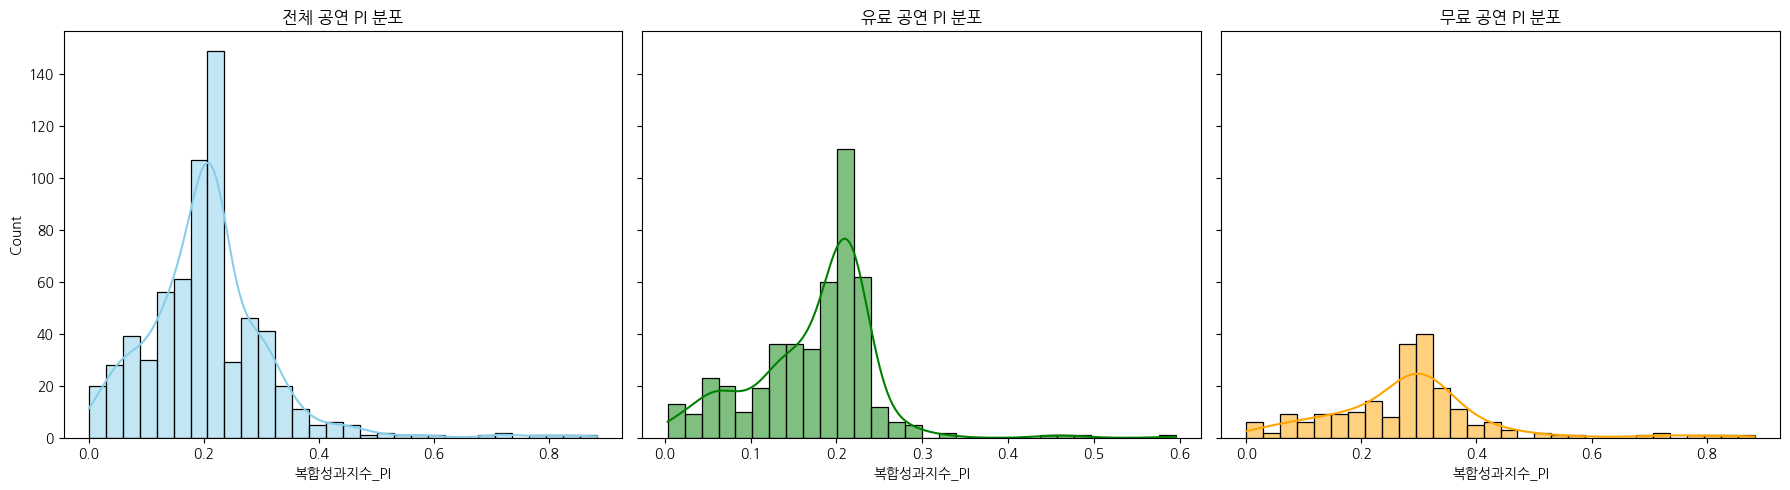

In [30]:

# 공연유형 구분
is_free = (df["회차당매출"].fillna(0) == 0) & (df["평균판매단가"].fillna(0) == 0)
df["공연유형"] = "전체"
df.loc[~is_free, "공연유형"] = "유료"
df.loc[is_free, "공연유형"] = "무료"

# 시각화: 가로로 나란히 3개
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 전체
sns.histplot(df["복합성과지수_PI"].dropna(), kde=True, bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("전체 공연 PI 분포")

# 유료
sns.histplot(df.loc[df["공연유형"]=="유료", "복합성과지수_PI"].dropna(), kde=True, bins=30, ax=axes[1], color="green")
axes[1].set_title("유료 공연 PI 분포")

# 무료
sns.histplot(df.loc[df["공연유형"]=="무료", "복합성과지수_PI"].dropna(), kde=True, bins=30, ax=axes[2], color="orange")
axes[2].set_title("무료 공연 PI 분포")

plt.tight_layout()
plt.show()


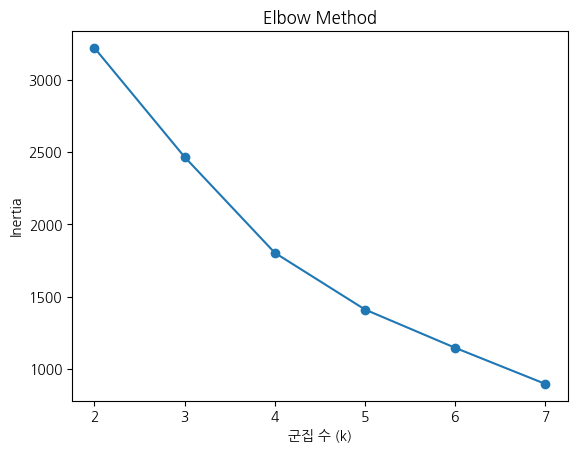

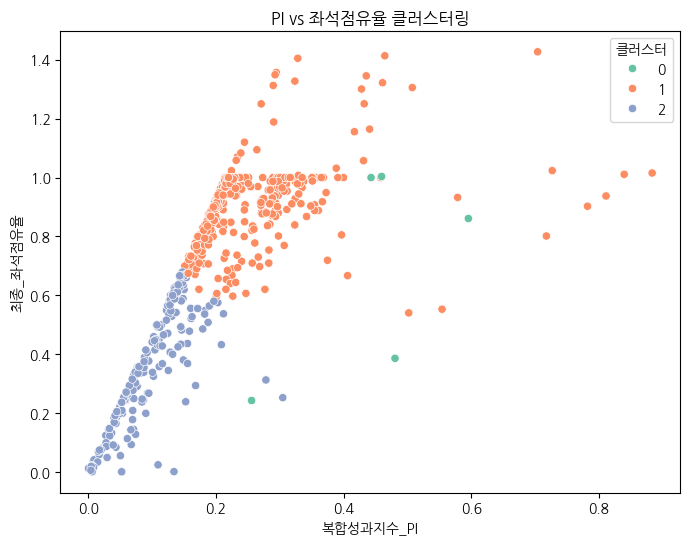

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ===== 1) 사용할 변수 선택 (PI 포함)
features = ["복합성과지수_PI", "최종_좌석점유율", "판매좌석수_합계", "회차당매출", "평균판매단가", "총_공연회차_x"]

df_clust = df[features].dropna()

# ===== 2) 상대지표화 (표준화)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# ===== 3) 최적 군집 수 찾기 (엘보우)
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("군집 수 (k)")
plt.ylabel("Inertia")
plt.show()

# ===== 4) 클러스터링 (예: k=3)
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df["클러스터"] = km.fit_predict(X_scaled)

# ===== 5) 시각화 (PI vs 좌석점유율)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="복합성과지수_PI", y="최종_좌석점유율", hue="클러스터", palette="Set2")
plt.title("PI vs 좌석점유율 클러스터링")
plt.show()


In [32]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ===== 1) 사용할 컬럼 선택 =====
features = ["복합성과지수_PI", "최종_좌석점유율", "판매좌석수_합계",
            "회차당매출", "평균판매단가", "총_공연회차_x"]

df_clust = df[features].dropna()

# ===== 2) 상대지표화 (표준화) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# ===== 3) Silhouette Score 계산 (K=2~6) =====
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"K={k}, 실루엣 계수={score:.3f}")

# ===== 4) DataFrame으로 보기 편하게 정리 =====
score_df = pd.DataFrame(list(scores.items()), columns=["K", "Silhouette"])
display(score_df)


K=2, 실루엣 계수=0.418
K=3, 실루엣 계수=0.445
K=4, 실루엣 계수=0.443
K=5, 실루엣 계수=0.456
K=6, 실루엣 계수=0.491


,K,Silhouette
0,2,0.417798
1,3,0.444790
2,4,0.443398
3,5,0.455665
4,6,0.491304



=== K=4 군집별 평균값 ===


,복합성과지수_PI,최종_좌석점유율,판매좌석수_합계,회차당매출,평균판매단가,총_공연회차_x
클러스터,,,,,,
0,0.10,0.37,418.91,1822718.63,10217.03,3.16
1,0.25,0.92,843.93,4952851.71,8381.85,1.72
2,0.13,0.00,6.00,14415000.00,4805000.00,2.00
3,0.45,0.70,31622.20,76739630.25,23442.35,16.20


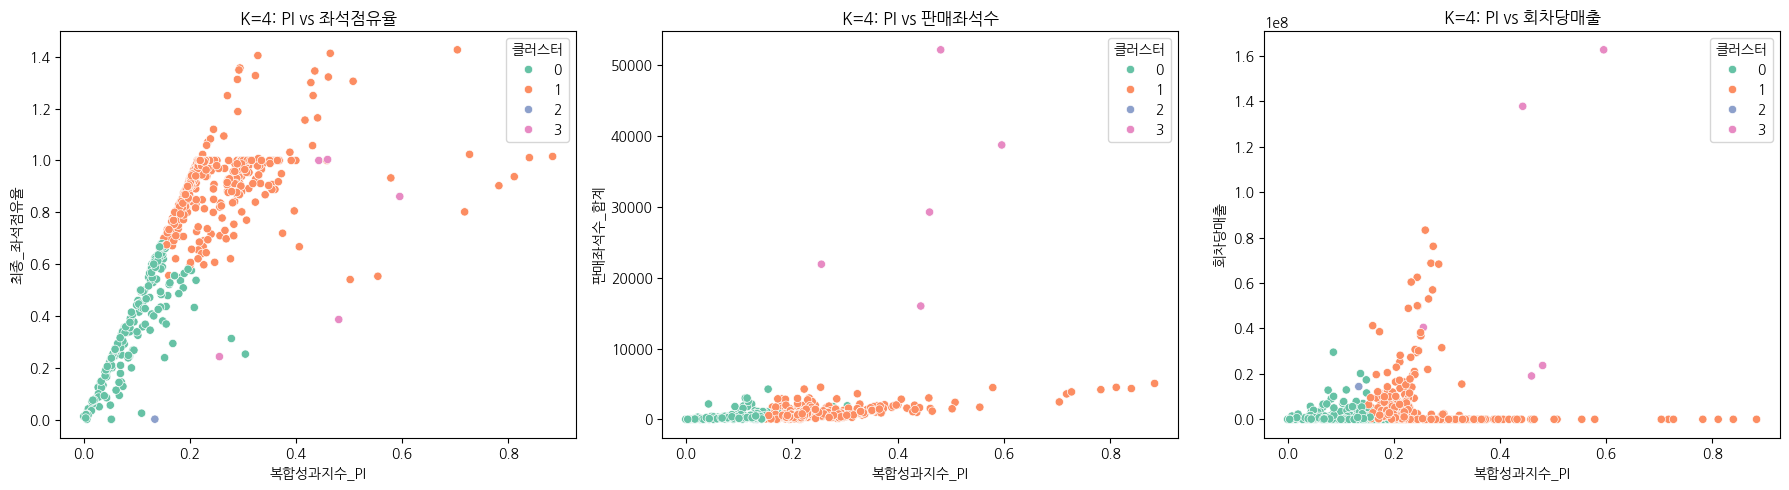


=== K=5 군집별 평균값 ===


,복합성과지수_PI,최종_좌석점유율,판매좌석수_합계,회차당매출,평균판매단가,총_공연회차_x
클러스터,,,,,,
0,0.24,0.92,795.02,5091229.07,8584.69,1.44
1,0.10,0.39,398.22,1862894.82,10092.99,1.99
2,0.45,0.70,31622.20,76739630.25,23442.35,16.20
3,0.13,0.00,6.00,14415000.00,4805000.00,2.00
4,0.47,0.59,2542.40,103298.73,4140.53,25.73


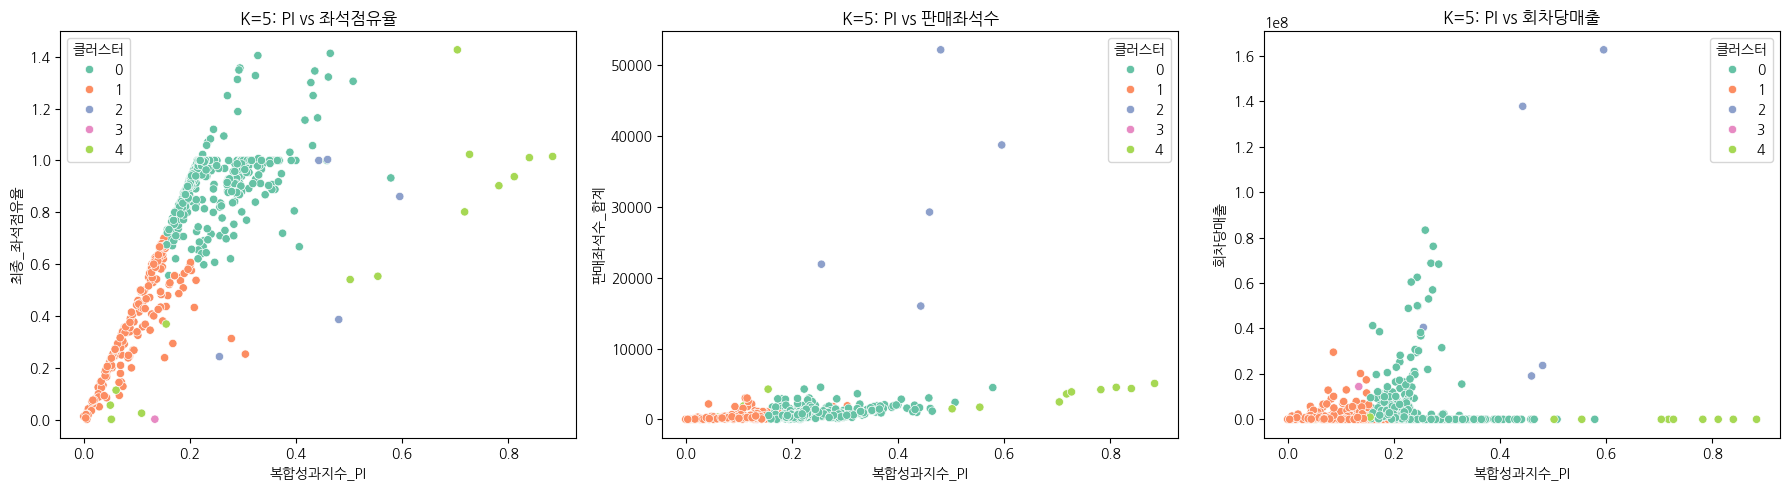


=== K=6 군집별 평균값 ===


,복합성과지수_PI,최종_좌석점유율,판매좌석수_합계,회차당매출,평균판매단가,총_공연회차_x
클러스터,,,,,,
0,0.24,0.90,1259.35,46330407.97,50409.55,1.22
1,0.24,0.92,766.74,2820013.03,6281.38,1.44
2,0.10,0.38,397.11,1894137.57,10221.92,2.01
3,0.13,0.00,6.00,14415000.00,4805000.00,2.00
4,0.47,0.59,2542.40,103298.73,4140.53,25.73
5,0.45,0.70,31622.20,76739630.25,23442.35,16.20


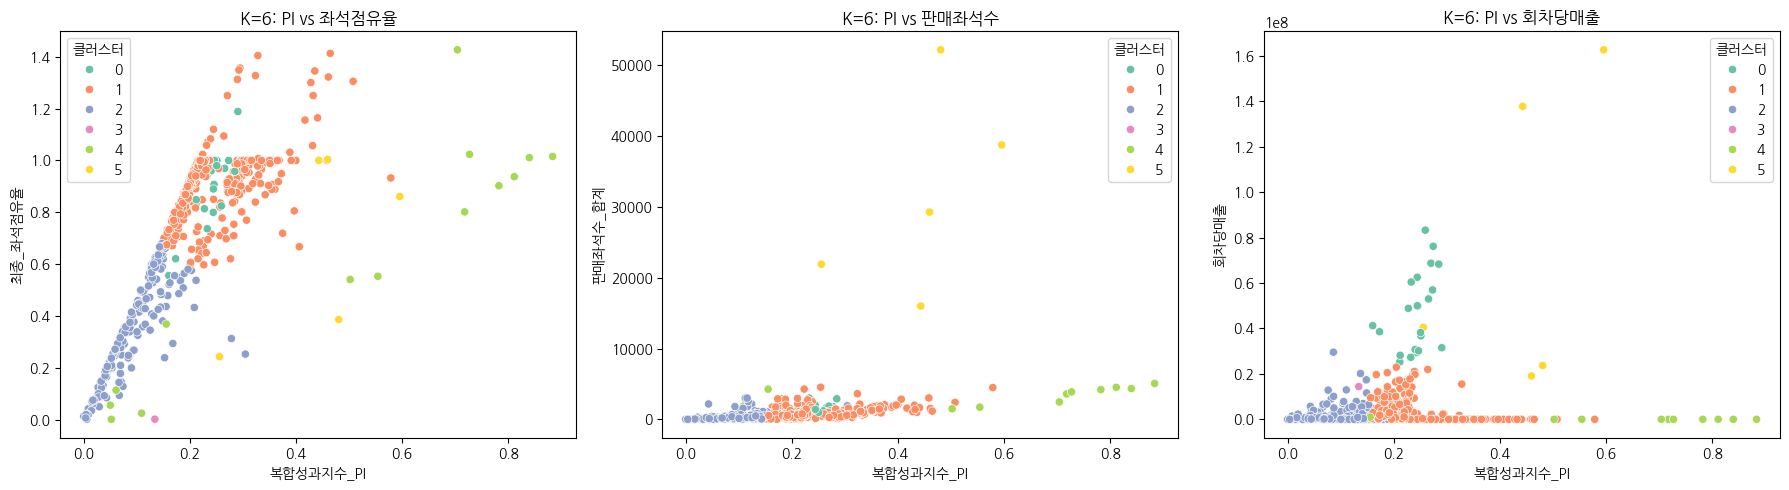

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ===== 1) 데이터 준비 =====
features = ["복합성과지수_PI", "최종_좌석점유율",
            "판매좌석수_합계", "회차당매출", "평균판매단가", "총_공연회차_x"]

df_clust = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# ===== 2) 비교할 K 값 =====
K_list = [4, 5, 6]
results = {}

for k in K_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    df_temp = df_clust.copy()
    df_temp["클러스터"] = labels

    # 군집별 평균값 요약
    summary = df_temp.groupby("클러스터").mean().round(2)
    results[k] = (df_temp, summary)

    print(f"\n=== K={k} 군집별 평균값 ===")
    display(summary)

    # ===== 3) 시각화 (항상 가로 3개) =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="최종_좌석점유율",
        hue="클러스터", palette="Set2", ax=axes[0]
    )
    axes[0].set_title(f"K={k}: PI vs 좌석점유율")

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="판매좌석수_합계",
        hue="클러스터", palette="Set2", ax=axes[1]
    )
    axes[1].set_title(f"K={k}: PI vs 판매좌석수")

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="회차당매출",
        hue="클러스터", palette="Set2", ax=axes[2]
    )
    axes[2].set_title(f"K={k}: PI vs 회차당매출")

    plt.tight_layout()
    plt.show()


=== K=5 군집별 평균값 및 라벨 ===


,복합성과지수_PI,최종_좌석점유율,판매좌석수_합계,회차당매출,평균판매단가,총_공연회차_x,설명라벨
클러스터,,,,,,,
0,0.24,0.90,1259.35,46330407.97,50409.55,1.22,안정적 중소규모형
1,0.24,0.92,766.74,2820013.03,6281.38,1.44,안정적 중소규모형
2,0.10,0.38,397.11,1894137.57,10221.92,2.01,저성과 소규모형
3,0.13,0.00,6.00,14415000.00,4805000.00,2.00,이상치/실패형
4,0.47,0.59,2542.40,103298.73,4140.53,25.73,장기 지속형
5,0.45,0.70,31622.20,76739630.25,23442.35,16.20,대형 흥행형


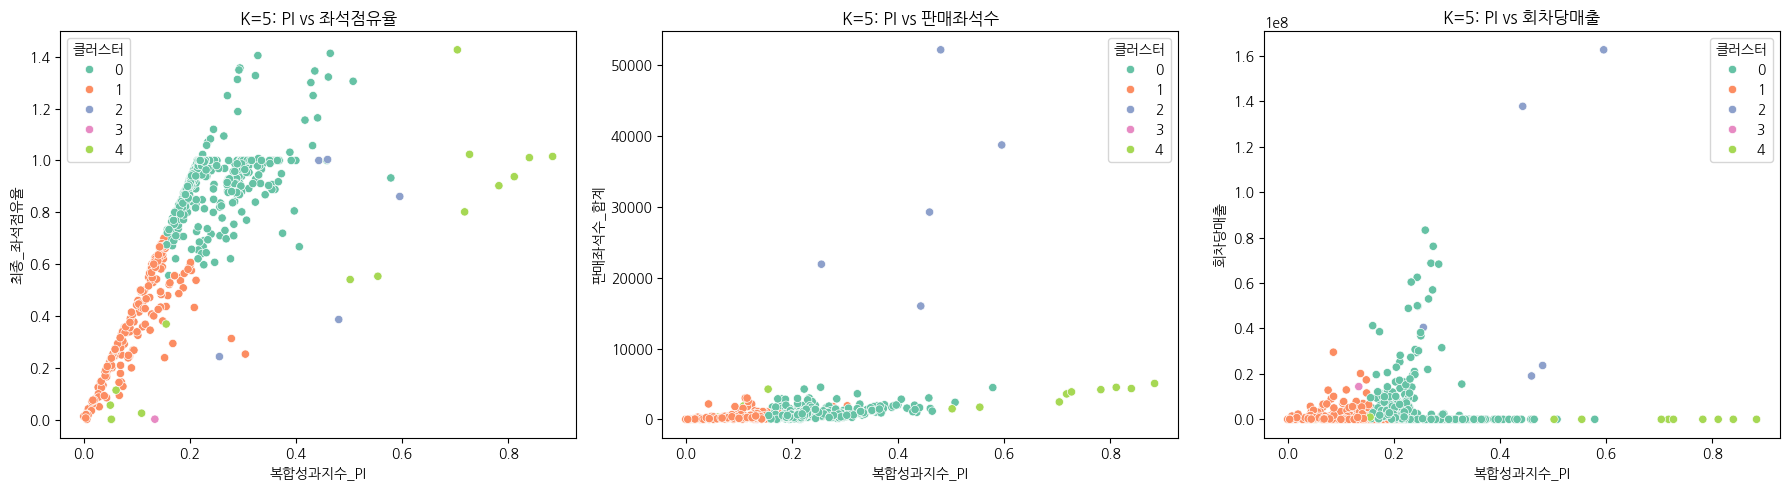

In [34]:
def label_cluster(row):
    # 기본 규칙 기반 라벨링
    if row["판매좌석수_합계"] < 50:
        return "이상치/실패형"
    if row["복합성과지수_PI"] > 0.4 and row["판매좌석수_합계"] > 10000:
        return "대형 흥행형"
    if row["최종_좌석점유율"] > 0.8 and row["판매좌석수_합계"] < 2000:
        return "안정적 중소규모형"
    if row["총_공연회차_x"] > 20 and row["회차당매출"] < 1e6:
        return "장기 지속형"
    if row["복합성과지수_PI"] < 0.2 and row["최종_좌석점유율"] < 0.5:
        return "저성과 소규모형"
    return "기타"

# 군집별 평균값 표 불러오기 (df_temp는 K=5 결과 클러스터링된 데이터)
summary = df_temp.groupby("클러스터")[[
    "복합성과지수_PI", "최종_좌석점유율", "판매좌석수_합계",
    "회차당매출", "평균판매단가", "총_공연회차_x"
]].mean().round(2)

# 라벨 자동 부여
summary["설명라벨"] = summary.apply(label_cluster, axis=1)

print("=== K=5 군집별 평균값 및 라벨 ===")
display(summary)

# ===== 2) 비교할 K 값 =====
K_list = [5]
results = {}

for k in K_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    df_temp = df_clust.copy()
    df_temp["클러스터"] = labels


    # ===== 3) 시각화 (항상 가로 3개) =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="최종_좌석점유율",
        hue="클러스터", palette="Set2", ax=axes[0]
    )
    axes[0].set_title(f"K={k}: PI vs 좌석점유율")

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="판매좌석수_합계",
        hue="클러스터", palette="Set2", ax=axes[1]
    )
    axes[1].set_title(f"K={k}: PI vs 판매좌석수")

    sns.scatterplot(
        data=df_temp, x="복합성과지수_PI", y="회차당매출",
        hue="클러스터", palette="Set2", ax=axes[2]
    )
    axes[2].set_title(f"K={k}: PI vs 회차당매출")

    plt.tight_layout()
    plt.show()


In [35]:
# ===== 2) 기본 세팅 & 유틸 =====
import numpy as np
import pandas as pd
from ast import literal_eval

df = df.copy()

# 열 이름 정리(있으면 통일)
if "총_공연회차_x" in df.columns and "총_공연회차" not in df.columns:
    df = df.rename(columns={"총_공연회차_x": "총_공연회차"})

# 숫자형 변환(문자 섞여 있어도 안전하게)
for col in ["최종_좌석점유율", "회차당매출", "평균판매단가", "판매좌석수_합계", "총_공연회차"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ---- 코호트 설정: 연도/분기 등 코호트 컬럼 있으면 여기 지정 (예: "연도")
cohort_col = None  # 예: "연도" 또는 "기간" 등. 없으면 None 그대로 두세요.

def winsorize_series(s: pd.Series, lower=0.05, upper=0.95, by: pd.Series | None=None):
    if by is None:
        lo, hi = s.quantile(lower), s.quantile(upper)
        return s.clip(lo, hi)
    else:
        qlo = s.groupby(by).transform(lambda x: x.quantile(lower))
        qhi = s.groupby(by).transform(lambda x: x.quantile(upper))
        return s.clip(qlo, qhi)

def percent_rank(s: pd.Series, by: pd.Series | None=None):
    # 백분위(0~1) 반환; NaN은 NaN 유지
    if by is None:
        return s.rank(pct=True, method="average")
    else:
        return s.groupby(by).rank(pct=True, method="average")

# ===== 3) 전처리: 윈저라이징 & 파생 기본 =====
# 극단값 완화 (코호트 내 적용; 없으면 전체)
by = df[cohort_col] if cohort_col and cohort_col in df.columns else None

df["_occ_w"]   = winsorize_series(df["최종_좌석점유율"], by=by)
df["_price_w"] = winsorize_series(df["평균판매단가"], by=by)
df["_rev_w"]   = winsorize_series(df["회차당매출"], by=by)
# 총 공연회차는 로그 변환 전에 0/음수 방지
df["_perf_log"] = np.log1p(df["총_공연회차"].fillna(0).clip(lower=0))

# ===== 4) 안정성(회차별 좌석점유율 CV) - 선택적 =====
# *현재 usecols에는 없지만, 만약 컬럼이 존재하면 자동 반영*
# - 형식1: 수치 리스트 문자열 "0.8,0.6,0.7" 혹은 "[0.8,0.6]"
# - 형식2: 이미 CV 값이 들어있는 열명 "회차별_좌석점유율_CV"가 있으면 그대로 사용
def _safe_parse_ratio_list(x):
    if pd.isna(x):
        return None
    if isinstance(x, (list, tuple)):
        return x
    try:
        val = literal_eval(str(x))
        if isinstance(val, (list, tuple)):
            return val
    except Exception:
        pass
    # "0.8,0.6,0.7" 같은 경우
    try:
        return [float(t) for t in str(x).split(",") if str(t).strip()!=""]
    except Exception:
        return None

if "회차별_좌석점유율" in df.columns and "회차별_좌석점유율_CV" not in df.columns:
    ratios = df["회차별_좌석점유율"].map(_safe_parse_ratio_list)
    means = ratios.map(lambda L: np.nanmean(L) if isinstance(L, (list, tuple)) and len(L)>0 else np.nan)
    stds  = ratios.map(lambda L: np.nanstd(L, ddof=0) if isinstance(L, (list, tuple)) and len(L)>0 else np.nan)
    df["회차별_좌석점유율_CV"] = stds / means

# ===== 5) 서브지수 계산: U(참여·안정), S(기회), A(가격접근성) =====
# U: 최종 점유율 백분위 × (안정성 역백분위) 의 기하평균
p_occ = percent_rank(df["_occ_w"], by=by)

if "회차별_좌석점유율_CV" in df.columns:
    # CV는 낮을수록 안정 → 역백분위(1 - rank)
    cv_w = winsorize_series(pd.to_numeric(df["회차별_좌석점유율_CV"], errors="coerce"), by=by)
    p_cv = percent_rank(cv_w, by=by)
    stab = 1 - p_cv
else:
    # 안정성 정보 없으면 중립(=1.0)로 처리
    stab = pd.Series(1.0, index=df.index)

U = np.sqrt((p_occ.clip(0,1)) * (stab.clip(0,1)))

# S: 기회/접점(회차 로그 백분위)
p_perf = percent_rank(winsorize_series(df["_perf_log"], by=by), by=by)
S = p_perf.clip(0,1)

# A: 가격 접근성(평균판매단가 백분위의 역수)
p_price = percent_rank(df["_price_w"], by=by)
A = (1 - p_price).clip(0,1)

# ===== 6) D-PI 산식 (유료/무료 동시 지원) =====
# 가중치 프리셋
wU_paid, wS_paid, wA_paid = 0.45, 0.35, 0.20
wU_free, wS_free          = 0.60, 0.40

# 유/무료 판단(간단 규칙): 평균판매단가<=0 또는 회차당매출<=0 → 무료로 간주
is_free = ((df["평균판매단가"].fillna(0) <= 0) | (df["회차당매출"].fillna(0) <= 0))

# Paid
geom_paid = (U.clip(1e-9,1)**wU_paid) * (S.clip(1e-9,1)**wS_paid) * (A.clip(1e-9,1)**wA_paid)
DPI_paid  = 100 * (geom_paid ** (1.0/(wU_paid + wS_paid + wA_paid)))

# Guardrail(유료): 회차당매출 하위 20%는 -5% 패널티
p_rev = percent_rank(df["_rev_w"], by=by)
guard = np.where((~is_free) & (p_rev < 0.20), 0.95, 1.00)
DPI_paid = DPI_paid * guard

# Free
geom_free = (U.clip(1e-9,1)**wU_free) * (S.clip(1e-9,1)**wS_free)
DPI_free  = 100 * (geom_free ** (1.0/(wU_free + wS_free)))

# 최종 선택
df["U_participation"] = U * 100
df["S_scale"]         = S * 100
df["A_afford"]        = A * 100
df["DPI_paid"]        = DPI_paid
df["DPI_free"]        = DPI_free
df["is_free"]         = is_free

df["DPI_final"] = np.where(is_free, DPI_free, DPI_paid)

# ===== 7) 결과 미리보기 =====
cols_show = [
    "최종_좌석점유율", "총_공연회차", "평균판매단가", "회차당매출",
    "U_participation", "S_scale", "A_afford", "DPI_final", "is_free"
]
print(df[cols_show].head(10))

# df.to_csv("DPI_result.csv", index=False, encoding="utf-8-sig")


# save_path = "/content/drive/MyDrive/KOPIS/Hyeon/DPI_result.csv"  # 폴더는 원하는 대로
# import os; os.makedirs(os.path.dirname(save_path), exist_ok=True)

# df.to_csv(save_path, index=False, encoding="utf-8-sig")
# print("Saved to:", save_path)


rank_cols = [
    "공연명","최종_좌석점유율","총_공연회차","평균판매단가","회차당매출",
    "U_participation","S_scale","A_afford","DPI_final","is_free"
]
rank_df = df.sort_values(
    ["DPI_final","U_participation","S_scale","A_afford"],
    ascending=[False, False, False, False]
)[rank_cols]

rank_df.to_csv("/content/drive/MyDrive/KOPIS/Hyeon/DPI_result.csv", index=False, encoding="utf-8-sig")

print("완료")


   최종_좌석점유율  총_공연회차        평균판매단가       회차당매출  U_participation    S_scale  \
0  0.719274       4      0.000000         0.0        61.022322  91.216216   
1  0.988048       1   2288.306452   1135000.0        87.765043  37.537538   
2  1.000000       2      0.000000         0.0        94.836670  80.555556   
3  0.033333       1  30000.000000     30000.0        16.209959  37.537538   
4  0.709725       1      0.000000         0.0        60.092521  37.537538   
5  0.597561       1      0.000000         0.0        51.260390  37.537538   
6  0.575545       1      0.000000         0.0        49.319696  37.537538   
7  1.094262       1  13707.865169  21960000.0        94.836670  37.537538   
8  0.992754       1      0.000000         0.0        88.870118  37.537538   
9  1.345109       1      0.000000         0.0        94.836670  37.537538   

    A_afford  DPI_final  is_free  
0  84.609610  71.667467     True  
1  55.555556  59.498118    False  
2  84.609610  88.843156     True  
3   7.582583